# Scoring consistency (mag245 n-body) — benchmark vs Sorcha, same object (MJD 61642)

mag245 n-body version of `nbody_scoring_consistency_night61642.ipynb`. Both sides are scored against the
**n-body maps** (`prob_maps_grid_s3m_nbody`) in Johnson V:
- benchmark: `outputs/phase2_benchmark_s3m_nbody_mag245/benchmark_comparison_s3m_nbody_mag245.parquet` (`P_NEO_vdp`)
- Sorcha:    `sorcha_comparison_case1_nbody_Vband.parquet` (`P_NEO_vdp_Vband`)

Sorcha is first sorted by `night, ObjID`, then restricted to night 61642 so the comparison remains
same-object and same-night. ΔP = Sorcha − benchmark, joined on `ObjID == s3m_objid`. The matched
set includes 794 NEOs plus matched non-NEOs needed to measure classification behavior.
Figures use a `mag245_nbody_` prefix so the original notebook outputs are preserved.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

NIGHT = 61642
GRID_LIM = 140.0
POP_COLORS = {'NEO':'tab:red','MBA':'tab:blue','TNO':'gold','Trojan':'mediumseagreen','Trojans':'mediumseagreen','other':'grey'}

BENCH_PATH = 'outputs/phase2_benchmark_s3m_nbody_mag245/benchmark_comparison_s3m_nbody_mag245.parquet'
SORCHA_PATH = 'sorcha_comparison_case1_nbody_Vband.parquet'

bench = pd.read_parquet(BENCH_PATH)
bench = bench[bench.dlon_from_antisun_deg.abs() <= GRID_LIM].copy()
bg = bench.set_index('s3m_objid')

sc_all = pd.read_parquet(SORCHA_PATH)
sc_all = sc_all.sort_values(['night', 'ObjID']).reset_index(drop=True)
sc = sc_all[sc_all.night == NIGHT].copy()

# identity join: bring in benchmark V mag + V score + map
j = sc.join(bg[['population','mean_mag','P_NEO_vdp','prob_map_file']].rename(
        columns={'population':'population_bench','mean_mag':'magV_b',
                 'P_NEO_vdp':'P_bench','prob_map_file':'pmf_b'}),
        on='ObjID', how='inner')
j = j.rename(columns={'population':'population_sorcha'})
j['dP']   = j.P_NEO_vdp_Vband - j.P_bench          # Sorcha(V) - benchmark(V)
j['dv']   = np.hypot(j.vlam - bg.vlam.reindex(j.ObjID).values,
                     j.vbeta - bg.vbeta.reindex(j.ObjID).values)
print(f'{len(j)} identity pairs on night {NIGHT}')
print(f"  matched benchmark NEOs: {(j.population_bench == 'NEO').sum()}")
print(f'  benchmark population counts: {j.population_bench.value_counts().to_dict()}')
print(f'  benchmark/Sorcha label mismatches: {(j.population_bench != j.population_sorcha).sum()}')
print(f'dP median={j.dP.median():+.4f}  |dP| median={j.dP.abs().median():.4f}  frac|dP|>0.05={100*(j.dP.abs()>0.05).mean():.1f}%')

1762 identity pairs on night 61642
  matched benchmark NEOs: 794
  benchmark population counts: {'MBA': 966, 'NEO': 794, 'TNO': 2}
  benchmark/Sorcha label mismatches: 49
dP median=+0.0000  |dP| median=0.0002  frac|dP|>0.05=6.0%


## Task 1 — magnitude, before vs after the V fix

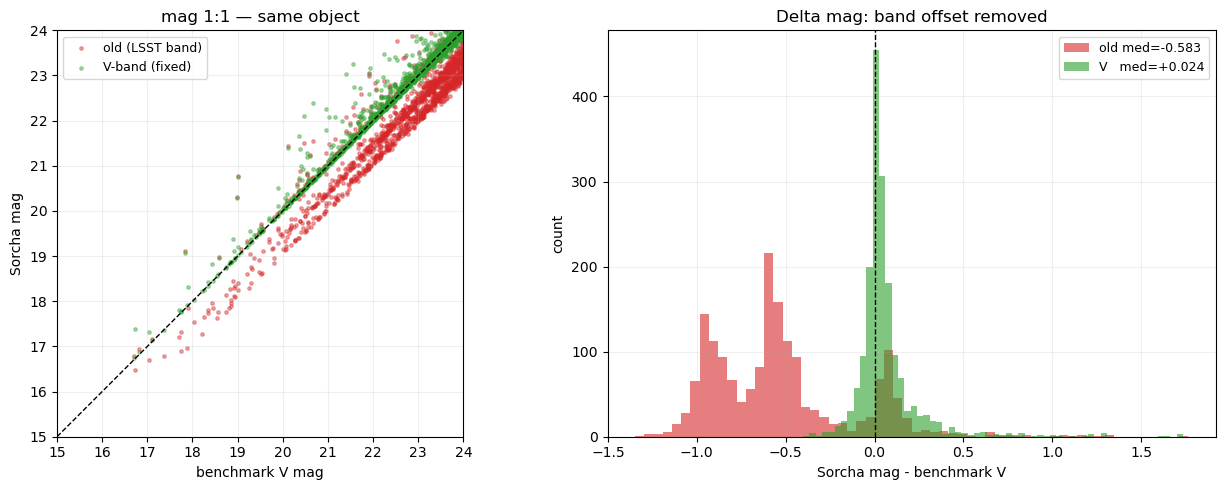

mag-bin crossing:  old (LSST) = 56.4%   ->   V-band = 10.0%


In [2]:
dmag_old = j.mean_mag   - j.magV_b     # Sorcha LSST mag - benchmark V
dmag_new = j.mean_mag_V - j.magV_b     # Sorcha V mag    - benchmark V

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(j.magV_b, j.mean_mag,   s=6, alpha=0.4, color='tab:red',  label='old (LSST band)')
axes[0].scatter(j.magV_b, j.mean_mag_V, s=6, alpha=0.4, color='tab:green', label='V-band (fixed)')
lim = [15, 24]
axes[0].plot(lim, lim, 'k--', lw=1)
axes[0].set_xlim(lim); axes[0].set_ylim(lim); axes[0].set_aspect('equal')
axes[0].set_xlabel('benchmark V mag'); axes[0].set_ylabel('Sorcha mag')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)
axes[0].set_title('mag 1:1 — same object')

axes[1].hist(dmag_old.clip(-2,2), bins=60, alpha=0.6, color='tab:red',  label=f'old med={dmag_old.median():+.3f}')
axes[1].hist(dmag_new.clip(-2,2), bins=60, alpha=0.6, color='tab:green', label=f'V   med={dmag_new.median():+.3f}')
axes[1].axvline(0, color='k', lw=1, ls='--')
axes[1].set_xlabel('Sorcha mag - benchmark V'); axes[1].set_ylabel('count')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.2)
axes[1].set_title('Delta mag: band offset removed')
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_sc_task1_mag.png', dpi=150, bbox_inches='tight')
plt.show()

# bin-crossing before vs after
def magbin(m):
    edges = [14,16,18,20,21,22,23,24]
    labs  = ['14_16','16_18','18_20','mag20','mag21','mag22','mag23']
    if m < 14: return None
    for e,l in zip(edges[1:], labs):
        if m < e: return l
    return 'mag24+'
cross_old = (j.mean_mag.map(magbin)   != j.magV_b.map(magbin)).mean()
cross_new = (j.mean_mag_V.map(magbin) != j.magV_b.map(magbin)).mean()
print(f'mag-bin crossing:  old (LSST) = {100*cross_old:.1f}%   ->   V-band = {100*cross_new:.1f}%')

## Sky map of identity-matched objects

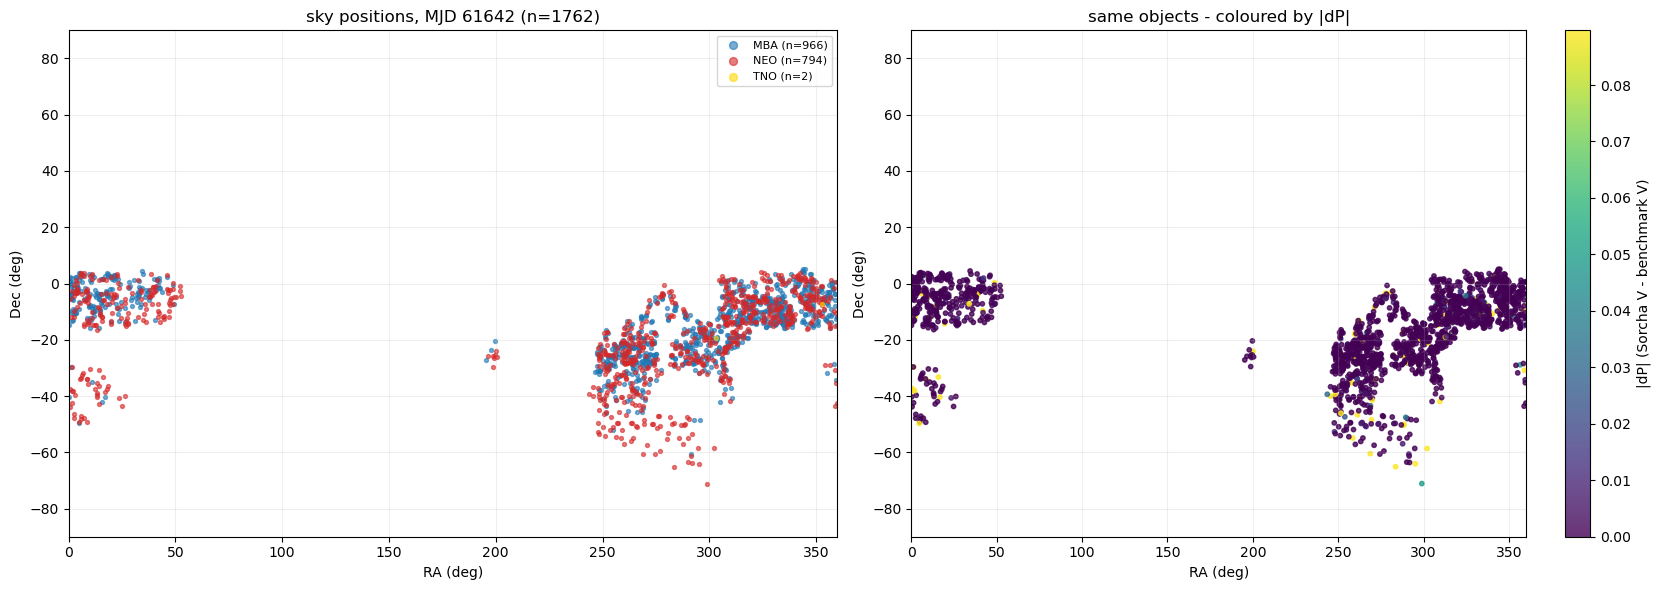

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for pop, g in j.groupby('population_bench'):
    axes[0].scatter(g.mean_ra, g.mean_dec, s=8, alpha=0.6, color=POP_COLORS.get(pop,'grey'), label=f'{pop} (n={len(g)})')
axes[0].set_xlim(0,360); axes[0].set_ylim(-90,90)
axes[0].set_xlabel('RA (deg)'); axes[0].set_ylabel('Dec (deg)')
axes[0].legend(fontsize=8, markerscale=2); axes[0].grid(alpha=0.2)
axes[0].set_title(f'sky positions, MJD {NIGHT} (n={len(j)})')

s = axes[1].scatter(j.mean_ra, j.mean_dec, s=10, alpha=0.8, c=j.dP.abs(), cmap='viridis', vmin=0, vmax=j.dP.abs().quantile(0.95))
fig.colorbar(s, ax=axes[1], label='|dP| (Sorcha V - benchmark V)')
axes[1].set_xlim(0,360); axes[1].set_ylim(-90,90)
axes[1].set_xlabel('RA (deg)'); axes[1].set_ylabel('Dec (deg)')
axes[1].grid(alpha=0.2)
axes[1].set_title('same objects - coloured by |dP|')
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_sc_skymap.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2 — 5x5 RA/Dec grid: ROC + median dP per cell

Same identity-matched objects. Benchmark `P_NEO_vdp` (blue) vs Sorcha `P_NEO_vdp_Vband` (red).

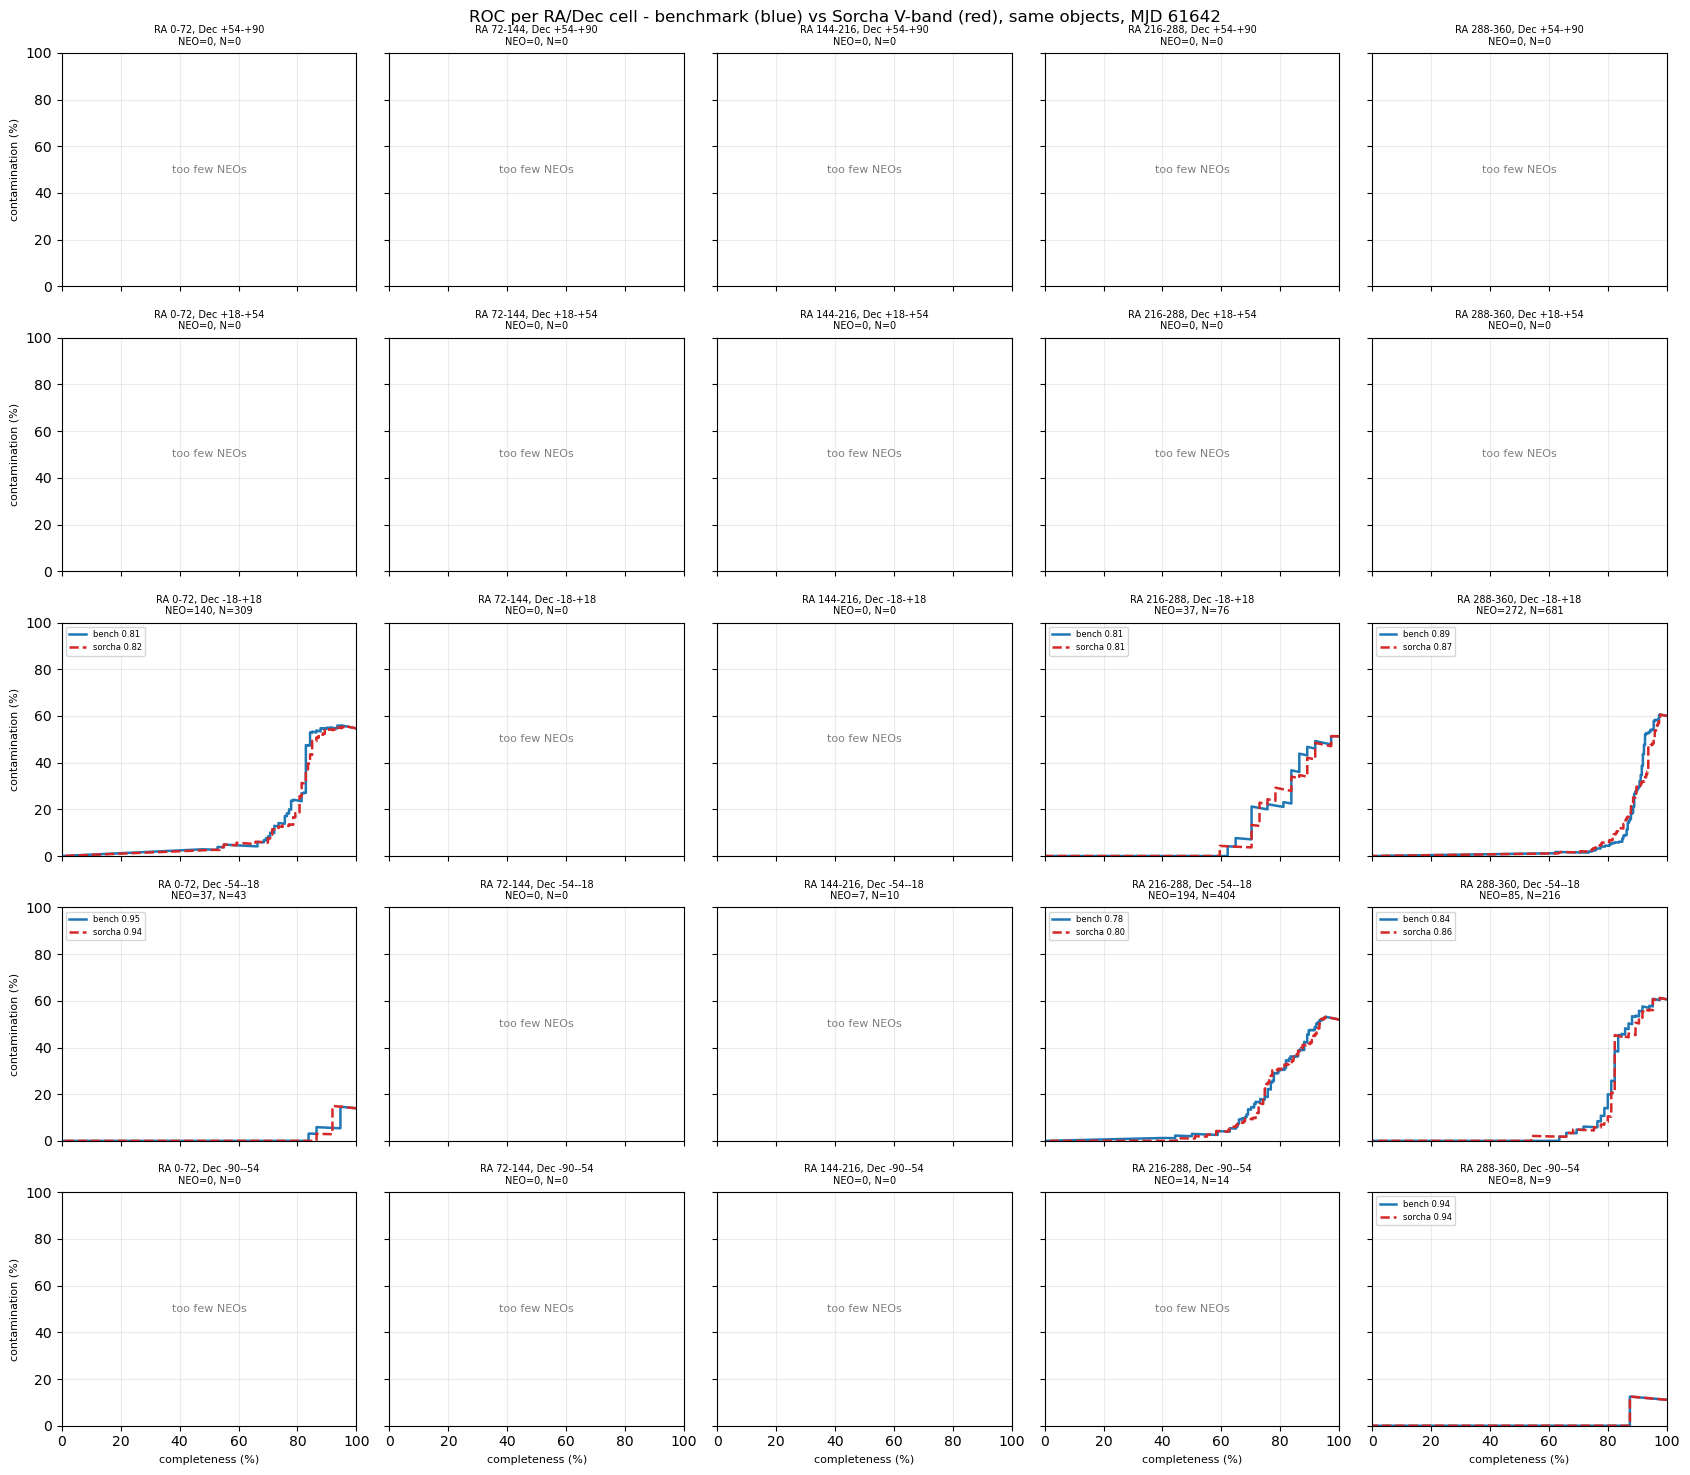

In [4]:
def roc_xy(y, s):
    p, r, _ = precision_recall_curve(y, s)
    f1 = np.divide(2*p*r, p+r, out=np.zeros_like(p), where=(p+r) > 0)
    bi = int(np.argmax(f1[:-1]))
    return r*100, (1-p)*100, f1[bi]

ra_e  = np.linspace(0, 360, 6)
dec_e = np.linspace(-90, 90, 6)
MIN_NEO = 8
y = (j.population_bench == 'NEO').astype(int).values

fig, axes = plt.subplots(5, 5, figsize=(17, 15), sharex=True, sharey=True)
for i in range(5):
    d_lo, d_hi = dec_e[4-i], dec_e[5-i]
    for k in range(5):
        r_lo, r_hi = ra_e[k], ra_e[k+1]
        ax = axes[i, k]
        m = ((j.mean_ra >= r_lo) & (j.mean_ra < r_hi) & (j.mean_dec >= d_lo) & (j.mean_dec < d_hi)).values
        yy = y[m]
        nneo = int(yy.sum())
        if nneo >= MIN_NEO and nneo < len(yy):
            cb, kb, fb = roc_xy(yy, j.P_bench.values[m])
            cs, ks, fs = roc_xy(yy, j.P_NEO_vdp_Vband.values[m])
            ax.plot(cb, kb, lw=1.8, color='tab:blue', label=f'bench {fb:.2f}')
            ax.plot(cs, ks, lw=1.8, color='tab:red', ls='--', label=f'sorcha {fs:.2f}')
            ax.legend(fontsize=6, loc='upper left')
        else:
            ax.text(0.5, 0.5, 'too few NEOs', ha='center', va='center', transform=ax.transAxes, fontsize=8, color='grey')
        ax.set_xlim(0,100); ax.set_ylim(0,100); ax.grid(alpha=0.25)
        ax.set_title(f'RA {r_lo:.0f}-{r_hi:.0f}, Dec {d_lo:+.0f}-{d_hi:+.0f}\nNEO={nneo}, N={m.sum()}', fontsize=7)
for ax in axes[-1,:]: ax.set_xlabel('completeness (%)', fontsize=8)
for ax in axes[:,0]: ax.set_ylabel('contamination (%)', fontsize=8)
fig.suptitle(f'ROC per RA/Dec cell - benchmark (blue) vs Sorcha V-band (red), same objects, MJD {NIGHT}', fontsize=12)
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_sc_task2_roc_grid.png', dpi=150, bbox_inches='tight')
plt.show()

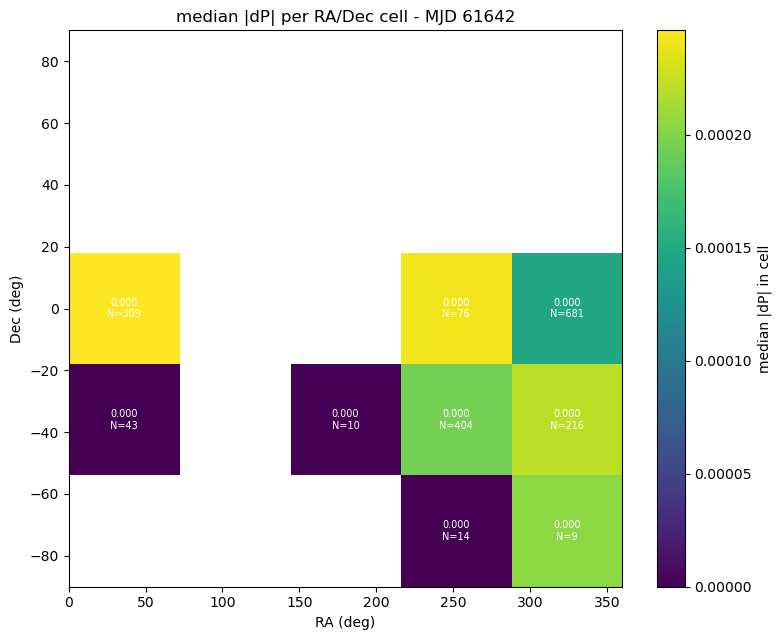

In [5]:
# median dP per cell (all objects, not just NEO)
grid = np.full((5,5), np.nan)
cnt  = np.zeros((5,5), int)
for i in range(5):
    d_lo, d_hi = dec_e[4-i], dec_e[5-i]
    for k in range(5):
        r_lo, r_hi = ra_e[k], ra_e[k+1]
        m = (j.mean_ra >= r_lo) & (j.mean_ra < r_hi) & (j.mean_dec >= d_lo) & (j.mean_dec < d_hi)
        if m.sum() > 0:
            grid[i,k] = j.dP[m].abs().median()
            cnt[i,k]  = m.sum()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(grid, cmap='viridis', vmin=0, vmax=np.nanquantile(grid, 0.9) or 0.01,
               extent=[0,360,-90,90], aspect='auto', origin='upper')
fig.colorbar(im, label='median |dP| in cell')
for i in range(5):
    for k in range(5):
        if cnt[i,k] > 0:
            ax.text(ra_e[k]+36, dec_e[4-i]+18, f'{grid[i,k]:.3f}\nN={cnt[i,k]}', ha='center', va='center', fontsize=7, color='white')
ax.set_xlabel('RA (deg)'); ax.set_ylabel('Dec (deg)')
ax.set_title(f'median |dP| per RA/Dec cell - MJD {NIGHT}')
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_sc_task2_dP_map.png', dpi=150, bbox_inches='tight')
plt.show()

### Task 2A - same-object benchmark/Sorcha score summary

This table uses the same identity-matched objects and benchmark population truth. It compares both classifiers on both pipeline realizations; the grouped bars show which classifier wins on F1 and ROC AUC.

,Dataset,Score,N,N_NEO,threshold,F1,completeness_%,contamination_%,ROC_AUC
0,Benchmark,VDP,1762,794,0.004,0.844,77.5,7.2,0.882
1,Sorcha,VDP,1762,794,0.003,0.840,80.7,12.6,0.886
2,Benchmark,digest2,1762,794,0.100,0.855,83.9,12.7,0.934
3,Sorcha,digest2,1762,794,0.270,0.855,79.1,7.0,0.930


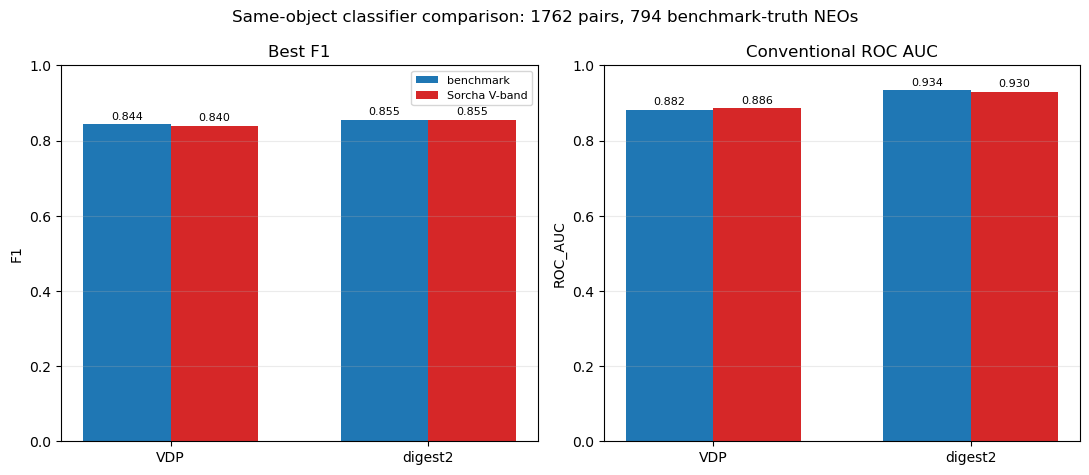

In [6]:
from sklearn.metrics import precision_recall_curve, roc_auc_score

# Add benchmark digest2 to the existing identity join.
j['P_bench_d2'] = bg['P_NEO_d2'].reindex(j.ObjID).to_numpy()
assert j['P_bench_d2'].notna().all(), 'Some identity-matched rows are missing benchmark digest2 scores'

def matched_score_metrics(dataset, score_label, score_column):
    yy = j.population_bench.eq('NEO').astype(int).to_numpy()
    ss = j[score_column].to_numpy()
    p, r, thresholds = precision_recall_curve(yy, ss)
    f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)
    bi = int(np.argmax(f1[:-1]))
    return {
        'Dataset': dataset,
        'Score': score_label,
        'N': len(j),
        'N_NEO': int(yy.sum()),
        'threshold': thresholds[bi],
        'F1': f1[bi],
        'completeness_%': r[bi] * 100,
        'contamination_%': (1 - p[bi]) * 100,
        'ROC_AUC': roc_auc_score(yy, ss),
    }

score_specs = [
    ('Benchmark', 'VDP', 'P_bench'),
    ('Sorcha', 'VDP', 'P_NEO_vdp_Vband'),
    ('Benchmark', 'digest2', 'P_bench_d2'),
    ('Sorcha', 'digest2', 'P_NEO_d2'),
]
score_summary = pd.DataFrame([matched_score_metrics(*spec) for spec in score_specs])
display(score_summary.style.format({
    'threshold': '{:.3f}', 'F1': '{:.3f}',
    'completeness_%': '{:.1f}', 'contamination_%': '{:.1f}', 'ROC_AUC': '{:.3f}'
}))

# Grouped bars: classifier on the x-axis, benchmark/Sorcha realization by color.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
x = np.arange(2)
width = 0.34
benchmark_rows = score_summary[score_summary.Dataset.eq('Benchmark')].set_index('Score').loc[['VDP', 'digest2']]
sorcha_rows = score_summary[score_summary.Dataset.eq('Sorcha')].set_index('Score').loc[['VDP', 'digest2']]
for ax, metric, title in zip(axes, ['F1', 'ROC_AUC'], ['Best F1', 'Conventional ROC AUC']):
    b = ax.bar(x - width / 2, benchmark_rows[metric], width, color='tab:blue', label='benchmark')
    s = ax.bar(x + width / 2, sorcha_rows[metric], width, color='tab:red', label='Sorcha V-band')
    ax.set_xticks(x, ['VDP', 'digest2'])
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    ax.bar_label(b, fmt='%.3f', padding=2, fontsize=8)
    ax.bar_label(s, fmt='%.3f', padding=2, fontsize=8)
axes[0].legend(fontsize=8)
fig.suptitle(f'Same-object classifier comparison: {len(j)} pairs, {int(j.population_bench.eq("NEO").sum())} benchmark-truth NEOs')
fig.tight_layout()
plt.savefig('Figures/mag245_nbody_sc_task2_matched_score_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 3 — which objects have differing scores, and why

dP = Sorcha `P_NEO_vdp_Vband` - benchmark `P_NEO_vdp`. Attribute the outliers (|dP| > 0.05).

outliers (|dP|>0.05): 106 / 1762 (6.0%)
  of outliers:  bin_cross=8%   map_diff=25%   |dv|>0.1=0%
  benchmark population mix: {'NEO': np.int64(98), 'MBA': np.int64(8)}


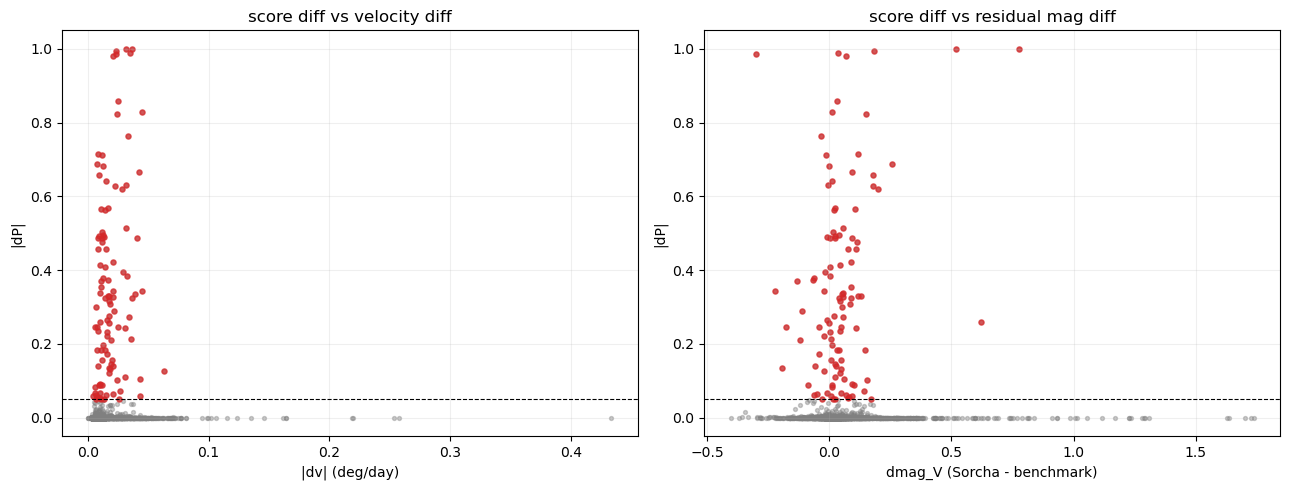

In [7]:
j['dmagV']    = j.mean_mag_V - j.magV_b
j['bin_cross']= j.mean_mag_V.map(magbin) != j.magV_b.map(magbin)
j['map_diff'] = j.prob_map_file != j.pmf_b
j['outlier']  = j.dP.abs() > 0.05

out = j[j.outlier]
print(f'outliers (|dP|>0.05): {len(out)} / {len(j)} ({100*len(out)/len(j):.1f}%)')
print(f'  of outliers:  bin_cross={100*out.bin_cross.mean():.0f}%   map_diff={100*out.map_diff.mean():.0f}%   |dv|>0.1={100*(out.dv>0.1).mean():.0f}%')
print(f'  benchmark population mix: {dict(out.population_bench.value_counts())}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(j.dv, j.dP.abs(), s=8, alpha=0.4, color='grey')
axes[0].scatter(out.dv, out.dP.abs(), s=14, alpha=0.7, color='tab:red')
axes[0].axhline(0.05, color='k', ls='--', lw=0.8)
axes[0].set_xlabel('|dv| (deg/day)'); axes[0].set_ylabel('|dP|')
axes[0].grid(alpha=0.2); axes[0].set_title('score diff vs velocity diff')

axes[1].scatter(j.dmagV, j.dP.abs(), s=8, alpha=0.4, color='grey')
axes[1].scatter(out.dmagV, out.dP.abs(), s=14, alpha=0.7, color='tab:red')
axes[1].axhline(0.05, color='k', ls='--', lw=0.8)
axes[1].set_xlabel('dmag_V (Sorcha - benchmark)'); axes[1].set_ylabel('|dP|')
axes[1].grid(alpha=0.2); axes[1].set_title('score diff vs residual mag diff')
plt.tight_layout()
plt.savefig('Figures/mag245_nbody_sc_task3_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# attribution table: classify each outlier by dominant cause
def cause(r):
    if r.dv > 0.1:            return 'velocity tail'
    if r.map_diff:            return 'map mismatch'
    if r.bin_cross:           return 'mag-bin cross'
    if abs(r.dmagV) > 0.2:    return 'residual photometry'
    if 0.1 < r.P_bench < 0.9: return 'boundary NEO'
    return 'unexplained'
out = out.copy()
out['cause'] = out.apply(cause, axis=1)
print('outlier attribution:')
display(out.cause.value_counts().to_frame('n_objects'))
print('\nlargest |dP| outliers:')
display(out.reindex(out.dP.abs().sort_values(ascending=False).index)
           [['ObjID','population_bench','population_sorcha','dP','dv','dmagV','bin_cross','map_diff','cause']].head(12))

outlier attribution:


,n_objects
cause,
boundary NEO,44
unexplained,27
map mismatch,27
mag-bin cross,5
residual photometry,3



largest |dP| outliers:


,ObjID,population_bench,population_sorcha,dP,dv,dmagV,bin_cross,map_diff,cause
561276,S0000NWGa,NEO,NEO,-1.000000,0.036634,0.520243,False,False,residual photometry
561361,S0000e92a,NEO,NEO,1.000000,0.031263,0.776717,False,False,residual photometry
561431,S0000kyza,NEO,NEO,-0.992866,0.023663,0.184788,False,True,map mismatch
561240,S0000BUga,NEO,NEO,-0.987284,0.035285,0.034928,False,False,unexplained
561484,S0000t4oa,NEO,NEO,-0.984599,0.023609,-0.299323,True,True,map mismatch
561311,S0000alqa,NEO,NEO,0.980992,0.020946,0.067908,False,True,map mismatch
561213,S00008bfa,NEO,NEO,0.858592,0.024725,0.030580,False,False,boundary NEO
561472,S0000qNMa,NEO,NEO,-0.829873,0.044807,0.010614,False,False,unexplained
561456,S0000o28a,NEO,NEO,-0.822819,0.024031,0.151540,False,True,map mismatch
561523,S000177da,NEO,NEO,-0.763999,0.033498,-0.032642,False,False,boundary NEO


In [9]:
# side-by-side dump of one object: Sorcha vs benchmark
# Default to the largest score-disagreement object in this mag245 identity join.
OID = (out.loc[out.dP.abs().idxmax(), 'ObjID'] if len(out) else j.iloc[0].ObjID)
AU  = 1.495978707e8        # km

rs = sc[sc.ObjID == OID].iloc[0]
rb = bench[bench.s3m_objid == OID].iloc[0]

# (label, sorcha value, benchmark value)  -- None where a side has no equivalent
rows = [
    ('population',        rs.population,        rb.population),
    ('RA (deg)',          rs.mean_ra,           rb.mean_ra),
    ('Dec (deg)',         rs.mean_dec,          rb.mean_dec),
    ('ecl lon (deg)',     rs.ecl_lon,           rb.lam_deg),
    ('ecl lat (deg)',     rs.ecl_lat,           rb.beta_deg),
    ('dlon from antisun', None,                 rb.dlon_from_antisun_deg),
    ('vlam (deg/day)',    rs.vlam,              rb.vlam),
    ('vbeta (deg/day)',   rs.vbeta,             rb.vbeta),
    ('|v| (deg/day)',     np.hypot(rs.vlam, rs.vbeta), np.hypot(rb.vlam, rb.vbeta)),
    ('mean_mag',          rs.mean_mag,          rb.mean_mag),
    ('mean_mag_V',        rs.mean_mag_V,        rb.mean_mag),
    ('mag0 / mag1',       f'{rs.mag0:.3f} / {rs.mag1:.3f}', f'{rb.mag0:.3f} / {rb.mag1:.3f}'),
    ('filter0 / filter1', f'{rs.filter0} / {rs.filter1}',   'V (synthetic)'),
    ('snr0 / snr1',       f'{rs.snr0:.2f} / {rs.snr1:.2f}', None),
    ('H (abs mag)',       f'H_r={rs.H_r:.3f}',  f'H_V={rb.H}'),
    ('range topo (AU)',   rs.range_km/AU,       None),
    ('range helio (AU)',  rs.obj_sun_km/AU,     None),
    ('a_au / e / q_au',   f'{rs.a_au:.3f} / {rs.e:.3f} / {rs.q_au:.3f}', f'e={rb.e:.3f}'),
    ('mjd0_utc',          rs.mjd0_utc,          rb.mjd0_utc),
    ('mjd1_utc',          rs.mjd1_utc,          rb.mjd1_utc),
    ('dt (min)',          rs.dt_min,            (rb.mjd1_utc-rb.mjd0_utc)*1440),
    ('prob_map_file',     rs.prob_map_file,     rb.prob_map_file),
    ('P_NEO_vdp',         rs.P_NEO_vdp,         rb.P_NEO_vdp),
    ('P_NEO_vdp_Vband',   rs.P_NEO_vdp_Vband,   rb.P_NEO_vdp),
    ('P_NEO_d2',          getattr(rs, 'P_NEO_d2', None),  getattr(rb, 'P_NEO_d2', None)),
]
def fmt(v):
    if v is None: return '-'
    return f'{v:.6f}' if isinstance(v, (float, np.floating)) else str(v)
tbl = pd.DataFrame([(l, fmt(s), fmt(b)) for l, s, b in rows], columns=['field', 'Sorcha', 'benchmark'])
print(f'=== {OID} ===')
display(tbl.set_index('field'))

# derived comparison
d1, d2 = np.radians(rb.mean_dec), np.radians(rs.mean_dec)
sep = np.degrees(np.arccos(np.clip(np.sin(d1)*np.sin(d2) +
      np.cos(d1)*np.cos(d2)*np.cos(np.radians(rb.mean_ra - rs.mean_ra)), -1, 1)))
dv = np.hypot(rs.vlam - rb.vlam, rs.vbeta - rb.vbeta)
hrs = (rs.mjd0_utc - rb.mjd0_utc) * 24
print(f'sky separation   = {sep:.3f} deg')
print(f'|dv|             = {dv:.4f} deg/day')
print(f'dP (V-band)      = {rs.P_NEO_vdp_Vband - rb.P_NEO_vdp:+.4f}')
print(f'dmag_V           = {rs.mean_mag_V - rb.mean_mag:+.4f}')
print(f'Sorcha obs is    = {hrs:.2f} h after benchmark epoch')
print(f'motion expected in that gap (bench rate x dt) = {np.hypot(rb.vlam, rb.vbeta)*hrs/24:.3f} deg  -> observed sep {sep:.2f} deg')

=== S0000NWGa ===


,Sorcha,benchmark
field,,
population,NEO,NEO
RA (deg),1.490133,2.149954
Dec (deg),-29.696861,-30.274829
ecl lon (deg),348.517229,348.804272
ecl lat (deg),-27.614248,-28.387638
dlon from antisun,-,17.601272
vlam (deg/day),-0.703391,-0.674075
vbeta (deg/day),2.007422,1.985453
|v| (deg/day),2.127088,2.096759


sky separation   = 0.813 deg
|dv|             = 0.0366 deg/day
dP (V-band)      = -1.0000
dmag_V           = +0.5202
Sorcha obs is    = 9.13 h after benchmark epoch
motion expected in that gap (bench rate x dt) = 0.798 deg  -> observed sep 0.81 deg


## Task 2B - poster crop: two well-matched sky cells

The full grid contains two especially useful cells for the poster: NEO=194 and NEO=272. This section reproduces those two benchmark/Sorcha operating curves only, stacked vertically with square axes.

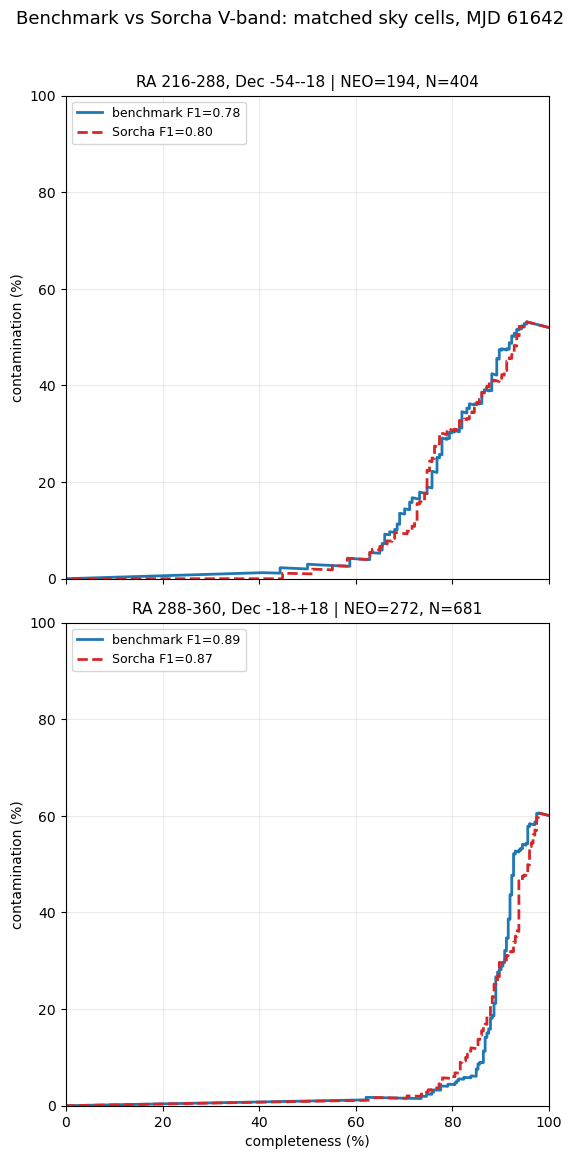

In [10]:
poster_cells = [
    {'ra_lo': 216, 'ra_hi': 288, 'dec_lo': -54, 'dec_hi': -18},  # NEO=194
    {'ra_lo': 288, 'ra_hi': 360, 'dec_lo': -18, 'dec_hi': 18},   # NEO=272
]

fig, axes = plt.subplots(2, 1, figsize=(5.8, 11.6), sharex=True, sharey=True)
for ax, cell in zip(axes, poster_cells):
    r_lo, r_hi = cell['ra_lo'], cell['ra_hi']
    d_lo, d_hi = cell['dec_lo'], cell['dec_hi']
    m = ((j.mean_ra >= r_lo) & (j.mean_ra < r_hi) &
         (j.mean_dec >= d_lo) & (j.mean_dec < d_hi)).values
    yy = y[m]
    nneo = int(yy.sum())
    nobj = int(m.sum())
    cb, kb, fb = roc_xy(yy, j.P_bench.values[m])
    cs, ks, fs = roc_xy(yy, j.P_NEO_vdp_Vband.values[m])
    ax.plot(cb, kb, lw=2.0, color='tab:blue', label=f'benchmark F1={fb:.2f}')
    ax.plot(cs, ks, lw=2.0, color='tab:red', ls='--', label=f'Sorcha F1={fs:.2f}')
    ax.set_title(f'RA {r_lo}-{r_hi}, Dec {d_lo:+.0f}-{d_hi:+.0f} | NEO={nneo}, N={nobj}', fontsize=11)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_box_aspect(1)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, loc='upper left')

axes[0].set_ylabel('contamination (%)')
axes[1].set_ylabel('contamination (%)')
axes[1].set_xlabel('completeness (%)')
fig.suptitle(f'Benchmark vs Sorcha V-band: matched sky cells, MJD {NIGHT}', fontsize=13, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('Figures/mag245_nbody_sc_task2_good_match_cells.png', dpi=200, bbox_inches='tight')
plt.savefig('Figures/mag245_nbody_sc_task2_good_match_cells.pdf', bbox_inches='tight')
plt.show()